# Linear inversion examples

## Preliminary steps

### Importing necessary libraries

In [1]:
#Adding library modules to PYTHONPATH
import sys
sys.path.append("../python")
import numpy as np
#Inversion library-related modules
import pyVector as Vec
import pyOperator as Op
import pyLCGsolver as LCG
import pySymLCGsolver as SymLCGsolver
import pyProblem as Prblm
import pyStopperBase as Stopper
#Testing the NLCG solver to optimize a regularized linear problem treated as if it was non linear
import pyNLCGsolver as NLCG
#Plotting library
from matplotlib import pyplot as plt

### Defining a matrix-vector multiplication operator

In [2]:
class MatMult(Op.Operator):
	"""Operator class to perform matrix-vector multiplication"""

	def __init__(self,A,domain,range):
		"""Constructor for the class: A = matrix to use; domain = domain vector; range = range vector"""
		if(not isinstance(domain,Vec.vector)): raise TypeError("ERROR! Domain vector not a vector object")
		if(not isinstance(range,Vec.vector)): raise TypeError("ERROR! Range vector not a vector object")
		#Setting domain and range of operator and matrix to use during application of the operator
		self.setDomainRange(domain,range)
		self.A = np.matrix(A)
		return

	def forward(self,add,model,data):
		"""Method to compute d = A m"""
		self.checkDomainRange(model,data)
		if(not isinstance(model,Vec.vectorIC)): raise TypeError("ERROR! Model vector not a vectorIC object")
		if(not isinstance(data,Vec.vectorIC)): raise TypeError("ERROR! Data vector not a vectorIC object")
		if(not add): data.zero()
		data.arr+=np.matmul(self.A,model.arr)
		return

	def adjoint(self,add,model,data):
		"""Method to compute m = A d"""
		self.checkDomainRange(model,data)
		if(not isinstance(model,Vec.vectorIC)): raise TypeError("ERROR! Model vector not a vectorIC object")
		if(not isinstance(data,Vec.vectorIC)): raise TypeError("ERROR! Data vector not a vectorIC object")
		if(not add): model.zero()
		model.arr+=np.matmul(self.A.H,data.arr)
		return

## Instantiation of vectors and operator

For testing the library we will be using a discretized version of the following operator:
\begin{align}
y = \frac{d^2f(x)}{dx^2},
\end{align}
in which we simply compute the second-order derivative of a function $f(x)$. 

In [3]:
N=200 #Number of points of the function f(x)
dx=1.0 #Sampling of the function
D2 = np.matrix(np.zeros((N,N),dtype=np.float64)) #Matrix containing the discretization of the derivative operator
#The stencil used is simply: (f(ix-1)-2f(ix)+f(ix+1))/(dx*dx)
np.fill_diagonal(D2, -2/(dx*dx))
np.fill_diagonal(D2[1:], 1/(dx*dx))
np.fill_diagonal(D2[:,1:], 1/(dx*dx))
f = Vec.vectorIC(np.zeros((N,1),dtype=np.float64)) #Initializing numpy-based vector for f(x)
y = Vec.vectorIC(np.zeros((N,1),dtype=np.float64)) #Initializing numpy-based vector for y
D2Op = MatMult(D2,f,y)

Before we set any inversion problem, we study some of the properties of the constructed operator Deriv2Op.

In [4]:
#Verifying operator adjointness through dot-product test
D2Op.dotTest(verbose=True)
#Computing maximum and minimum eigenvalues of the operator using the power iteration method and 
#compare them against the ones computed using numpy
egsOp=D2Op.powerMethod(verbose=False,eval_min=True,tol=1e-300)
egsNp,_=np.linalg.eig(D2)
egsNp = egsNp[egsNp.argsort()[::-1]] #Sorting the eigenvalues
print("\nMaximum eigenvalue: %s (Power method), %s (NUMPY)"%(egsOp[0],egsNp[-1]))
print("Minimum eigenvalue: %s (Power method), %s (NUMPY)"%(egsOp[1],egsNp[0]))

Dot-product test of forward and adjoint operators
-------------------------------------------------
Applying forward operator add=False
	Runs in: 0.00021696090698242188 seconds
Applying adjoint operator add=False
	Runs in: 0.00033283233642578125 seconds
Dot products add=False: domain=-3.169145474647562 range=-3.169145474647561 
Absolute error: 8.881784197001252e-16
Relative error: 2.802580149145407e-16 


Applying forward operator add=True
	Runs in: 0.0008339881896972656 seconds
Applying adjoint operator add=True
	Runs in: 0.0002579689025878906 seconds
Dot products add=True: domain=-6.338290949295124 range=-6.338290949295122 
Absolute error: 1.7763568394002505e-15
Relative error: 2.802580149145407e-16 

-------------------------------------------------

Maximum eigenvalue: -3.999755713875003 (Power method), -3.9997557138813002 (NUMPY)
Minimum eigenvalue: -0.000244286124993387 (Power method), -0.0002442861186948441 (NUMPY)


We can see that the matrix is negative definite. The small mismatch in the estimated eigenvalues is due to the dependence of the power method on the initial random eigenvector.

## Inversion tests

We will now focus our attention on inverting a function knowning its second-order derivative. In this case we will assume that $y$ is constant and equal to $1$. Therefore, we expect to obtain a parabola with positive curvature. Given the chosen boundary conditions we know that the matrix is invertible since all eigenvalues have the same sign and are different then zero.
We will solve the following objective functions using linear conjugate-gradient methods:
\begin{equation*}
\phi_1(\mathbf{f}) = \frac{1}{2}\|D_2\mathbf{f}-\mathbf{y}\|_2^2
\end{equation*}
and
\begin{equation*}
\phi_2(\mathbf{f}) = \frac{1}{2}\mathbf{f}^T D_2 \mathbf{f} - \mathbf{f}^{T} \mathbf{y},
\end{equation*}
where $D_2$ represents the discretized second-order derivative operator, while $\mathbf{f}$ and $\mathbf{y}$ are the discretized representations of $f$ and $y$, respectively.

In [5]:
y.set(1.0) # y = 1
#Note that f = 0
Phi1 = Prblm.ProblemL2Linear(f,y,D2Op)
Phi2 = Prblm.ProblemLinearSymmetric(f,y,D2Op)

### Instantiation of solver objects

First, we create two different solver object for solving the two inversion problem stated above.

In [6]:
#Create stopping criteria and related object
niter = 2000
Stop  = Stopper.BasicStopper(niter=niter)
#Create LCG solver
LCGsolver = LCG.LCGsolver(Stop)
LCGsolver.setDefaults(save_obj=True) #Saving objective function within the solver
#Create LCG solver for symmetric systems
SLCG = SymLCGsolver.SymLCGsolver(Stop)
SLCG.setDefaults(save_obj=True)

Secondly, we run the solvers to minimize the objective functions previously defined.

In [7]:
LCGsolver.run(Phi1,verbose=True)

LINEAR CONJUGATE GRADIENT SOLVER
Restart folder: /Users/ettorebiondi/.scratch/restart_2019-06-29T14-55-35.150065/

iter = 0 obj = 100.00000000000001 residual norm = 14.142135623730951 gradient norm= 1.4142135623730951 feval = 2
iter = 1 obj = 99.8 residual norm = 14.127986409959489 gradient norm= 1.1661903789690597 feval = 3
iter = 2 obj = 99.64829396325459 residual norm = 14.117244346065176 gradient norm= 1.0497703365932356 feval = 4
iter = 3 obj = 99.52078939803243 residual norm = 14.108209624047442 gradient norm= 0.9757096849579845 feval = 5
iter = 4 obj = 99.40857155873739 residual norm = 14.100253299762908 gradient norm= 0.9223321718092142 feval = 6
iter = 5 obj = 99.30715308864362 residual norm = 14.093058794218068 gradient norm= 0.8810795373069152 feval = 7
iter = 6 obj = 99.21389408350706 residual norm = 14.086439868434256 gradient norm= 0.8477320081849157 feval = 8
iter = 7 obj = 99.12708427153905 residual norm = 14.080275868855628 gradient norm= 0.8199134759060824 feval = 9
i

iter = 260 obj = 78.92628998519442 residual norm = 12.563939667571985 gradient norm= 0.009623909586799288 feval = 262
iter = 261 obj = 78.92625460855142 residual norm = 12.563936851843168 gradient norm= 0.017822591624646052 feval = 263
iter = 262 obj = 78.92623207601866 residual norm = 12.563935058413719 gradient norm= 0.01137892681544422 feval = 264
iter = 263 obj = 78.92615737379131 residual norm = 12.563929112645559 gradient norm= 0.034426448432163075 feval = 265
iter = 264 obj = 78.92590638199218 residual norm = 12.563909135455587 gradient norm= 0.04523806989360758 feval = 266
iter = 265 obj = 78.92567410579284 residual norm = 12.563890647868027 gradient norm= 0.05407693886283895 feval = 267
iter = 266 obj = 78.92297671230773 residual norm = 12.56367595191055 gradient norm= 0.22388113210379038 feval = 268
iter = 267 obj = 78.91358204506034 residual norm = 12.562928165444578 gradient norm= 0.17400097742121834 feval = 269
iter = 268 obj = 78.91176852924505 residual norm = 12.56278381

iter = 531 obj = 5.8557022650488574e-21 residual norm = 1.082192428826672e-10 gradient norm= 4.317155039885863e-12 feval = 533
iter = 532 obj = 5.854253476208942e-21 residual norm = 1.0820585452006691e-10 gradient norm= 2.3675194639694137e-12 feval = 534
iter = 533 obj = 5.850671651162245e-21 residual norm = 1.0817274750289229e-10 gradient norm= 3.92489782539939e-12 feval = 535
iter = 534 obj = 5.8446428492162145e-21 residual norm = 1.0811700004362139e-10 gradient norm= 6.766819695048544e-12 feval = 536
iter = 535 obj = 5.835048353296721e-21 residual norm = 1.0802822180612547e-10 gradient norm= 8.880713839790915e-12 feval = 537
iter = 536 obj = 5.830690545930443e-21 residual norm = 1.0798787474462532e-10 gradient norm= 2.351498137356853e-12 feval = 538
iter = 537 obj = 5.829986571187518e-21 residual norm = 1.0798135553129084e-10 gradient norm= 2.873826674413242e-12 feval = 539
iter = 538 obj = 5.827019525764071e-21 residual norm = 1.0795387464805579e-10 gradient norm= 7.793819603227112

In [8]:
SLCG.run(Phi2,verbose=True)

LINEAR CONJUGATE GRADIENT SOLVER FOR SYMMETRIC MATRIX
Restart folder: /Users/ettorebiondi/.scratch/restart_2019-06-29T14-55-35.150151/

iter = 0 obj = 0.0 residual norm = 14.142135623730951 feval = 1
iter = 1 obj = 10000.0 residual norm = 140.71247279470288 feval = 2
iter = 2 obj = 19801.0 residual norm = 139.2982411949268 feval = 3
iter = 3 obj = 29405.0 residual norm = 137.88400922514546 feval = 4
iter = 4 obj = 38814.0 residual norm = 136.46977687385584 feval = 5
iter = 5 obj = 48030.0 residual norm = 135.05554412907307 feval = 6
iter = 6 obj = 57055.0 residual norm = 133.64131097830492 feval = 7
iter = 7 obj = 65891.0 residual norm = 132.22707740852476 feval = 8
iter = 8 obj = 74540.0 residual norm = 130.81284340614266 feval = 9
iter = 9 obj = 83004.0 residual norm = 129.3986089569745 feval = 10
iter = 10 obj = 91285.0 residual norm = 127.98437404620925 feval = 11
iter = 11 obj = 99385.0 residual norm = 126.57013865837392 feval = 12
iter = 12 obj = 107306.0 residual norm = 125.1559

Finally, we can look at the results.

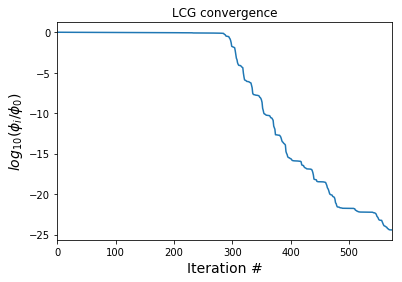

In [9]:
%matplotlib inline
plt.plot(np.log10(LCGsolver.obj/LCGsolver.obj[0]))
plt.title("LCG convergence")
plt.xlabel("Iteration #",fontsize=14)
plt.ylabel("$log_{10}$($\phi_i/\phi_0$)",fontsize=14)
ax = plt.gca() 
ax.autoscale(enable=True, axis='x', tight=True)

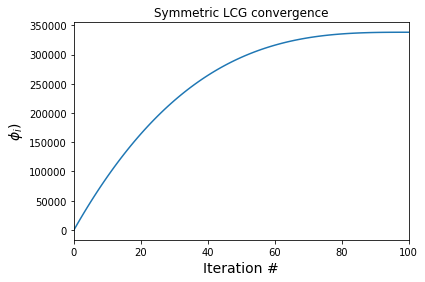

In [10]:
%matplotlib inline
plt.plot(SLCG.obj)
plt.title("Symmetric LCG convergence")
plt.xlabel("Iteration #",fontsize=14)
plt.ylabel("$\phi_i$)",fontsize=14)
ax = plt.gca() 
ax.autoscale(enable=True, axis='x', tight=True)

Also, let's compare the two inverted functions.

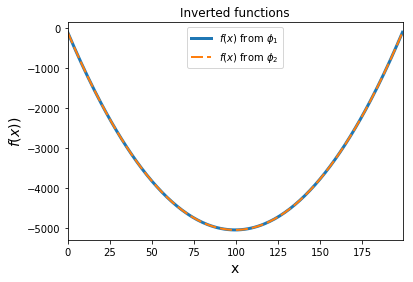

In [11]:
_ = plt.plot(Phi1.model.getNdArray(),linewidth=3,label="$f(x)$ from $\phi_1$")
_ = plt.plot(Phi2.model.getNdArray(),linewidth=2,dashes=[6, 2],label="$f(x)$ from $\phi_2$")
ax = plt.gca() 
ax.autoscale(enable=True, axis='x', tight=True)
ax.legend()
plt.xlabel("x",fontsize=14)
plt.ylabel("$f(x)$)",fontsize=14)
_ = plt.title("Inverted functions")

Now, let's try to solve both inversions using the inverse of $D_2$ as a preconditioner

In [12]:
PrecOp = MatMult(np.linalg.inv(D2),f,y) # P = [D_2]^-1
Phi1Prec = Prblm.ProblemL2Linear(f,y,D2Op,prec=Op.ChainOperator(PrecOp,PrecOp)) #In this line we chain [D_2]^-1 twice
Phi2Prec = Prblm.ProblemLinearSymmetric(f,y,D2Op,prec=PrecOp)

In [13]:
LCGsolver.setDefaults() # Re-setting default solver values
SLCG.setDefaults() # Re-setting default solver values

In [14]:
LCGsolver.run(Phi1Prec,verbose=True)

PRECONDITIONED LINEAR CONJUGATE GRADIENT SOLVER
Restart folder: /Users/ettorebiondi/.scratch/restart_2019-06-29T14-55-35.150065/

iter = 0 obj = 100.00000000000001 residual norm = 14.142135623730951 gradient norm= 1.4142135623730951 feval = 2
iter = 1 obj = 1.3363195206904904e-22 residual norm = 1.634820797941163e-11 gradient norm= 5.432522527466014e-11 feval = 3
iter = 2 obj = 3.157208759235713e-46 residual norm = 2.5128504767437768e-23 gradient norm= 1.4783890835778367e-23 feval = 4
Terminate: minimum residual tolerance reached 2.5128504767437768e-23



In [15]:
SLCG.run(Phi2Prec,verbose=True)

PRECONDITIONED LINEAR CONJUGATE GRADIENT SOLVER FOR SYMMETRIC MATRIX
Restart folder: /Users/ettorebiondi/.scratch/restart_2019-06-29T14-55-35.150151/

iter = 0 obj = 0.0 residual norm = 14.142135623730951 feval = 1
iter = 1 obj = 338350.0 residual norm = 1.566250240493278e-11 feval = 2
Objective function variation not monotonic, will terminate solver: obj_old=0.0 obj_cur=338350.0 obj_new=338350.0


As expected, we converge to the global minimum in effectively one iteration.